In [17]:
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns
import re
from glob import glob
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
colors = sns.color_palette('Blues')[::-1][2:]
hatchs = [None, '...', '||--', 'XXX']

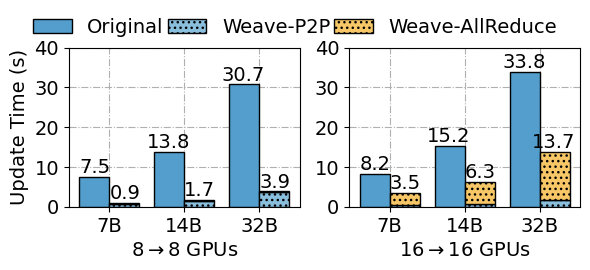

In [62]:
def parse_baseline(fn):
    with open(fn, 'r') as f:
        content = f.read()
    num = float(re.findall(r'Max Time \(Slowest Transfer\): (\d+.\d+) s', content)[0])
    return num

def parse_optimized(fn):
    with open(fn, 'r') as f:
        content = f.read()
    num = float(re.findall(r'Total End-to-End Time:\ +(\d+.\d+) s', content)[-1])
    s1 = float(re.findall(r"Stage 1 \(Max Shard Send\):\ +(\d+.\d+) s", content)[-1])
    s2 = float(re.findall(r"Stage 2 \(Gather Time\):\ +(\d+.\d+) s", content)[-1])
    return num, s1, s2


w = 0.4
_, axs = plt.subplots(1, 2, figsize=(6, 2.5))
for i, num_gpus in enumerate([16, 32]):
    plt.sca(axs[i])
    baseline_results = {}
    opt_results = {}
    for baseline_fn in glob(f"comm_results/results_{num_gpus}g/baseline*"):
        size = int(baseline_fn.split("_")[-1].strip(".0.out"))
        baseline_results[size] = parse_baseline(baseline_fn)

    for opt_fn in glob(f"comm_results/results_{num_gpus}g/scatter*"):
        size = int(opt_fn.split("_")[-1].strip(".0.out"))
        opt_results[size] = parse_optimized(opt_fn)
    plt.bar(np.arange(3), sorted(baseline_results.values()), width=w, color=colors[0], edgecolor='black', zorder=2, hatch=hatchs[0], label='Original' if i == 0 else None)
    opt_items = sorted(opt_results.values(), key=lambda i: i[0])
    opt_s1 = [i[1] for i in opt_items]
    opt_s2 = [i[2] for i in opt_items]
    plt.bar(np.arange(3) + w, opt_s1, width=w, color=colors[1], edgecolor='black', zorder=2, hatch=hatchs[1], label='Weave-P2P' if i == 0 else None)
    plt.bar(np.arange(3) + w, opt_s2, bottom=opt_s1, width=w, color="#F6C667", edgecolor='black', zorder=2, hatch=hatchs[1], label='Weave-AllReduce' if i == 0 else None)
    for idx, val in enumerate(sorted(baseline_results.values())):
        plt.text(idx - 0.1 * (len(f"{val:.1f}") - 1), val + 1, f"{val:.1f}", fontdict={"fontsize": 14})
    opt_values = sorted([i[0] for i in opt_results.values()])
    for idx, val in enumerate(opt_values):
        plt.text(idx + w - 0.1 * (len(f"{val:.1f}") - 1), val + 1, f"{val:.1f}", fontdict={"fontsize": 14})
    plt.xticks([i + w/2 for i in range(3)], [f"{i}B" for i in list(sorted(baseline_results.keys()))], fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, 40)
    if i == 0:
        plt.ylabel("Update Time (s)", fontdict={"fontsize": 14})
    plt.grid(linestyle="-.")
    plt.xlabel(f"{num_gpus//2}$\\rightarrow${num_gpus//2} GPUs", fontdict={"fontsize": 14})

lgd = plt.figlegend(ncols=3, fontsize=14, columnspacing=0.2, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()
plt.savefig("comm_opt.pdf", bbox_extra_artists=(lgd,), bbox_inches='tight')